In [1]:
import os
import scipy.io
import pandas as pd
import numpy as np
import re
import sys
from pathlib import Path
notebook_path = Path(sys.argv[0]).parent if "ipykernel" in sys.argv[0] else Path.cwd()
sys.path.append(str(notebook_path))
from utils import use  
from utils import make_data as mkdata
from utils import feature
from utils import classical_ml as cm
from utils import dbn_model as dbnm

In [2]:
# ===================== 主函数====================
def main_bearing_fault_diagnosis(
    pickle_path,
    save_dir,
    csv_save_dir,
    result_path,
    result_fig_path,
    window_size,
    step_size,
    config
):
    """
    主函数：轴承故障诊断完整流程（完全保留原始逻辑）
    参数：所有外部配置参数（与上面的外部配置一一对应）
    """
    # 确保保存目录存在（不改动你的核心逻辑，仅增加目录创建避免报错）
    for dir_path in [save_dir, csv_save_dir, result_path, result_fig_path]:
        os.makedirs(dir_path, exist_ok=True)
    
    # 1.读入原始数据，保存为npz数据集================================
    df = pd.read_pickle(pickle_path)

    # 对工况信息进行筛选
    filtered_df, cond_name = mkdata.filter_conditions(df, config)

    # 滑动窗口采样
    expanded_df = mkdata.expand_df_with_sliding_windows(filtered_df,
                                                 window_size=window_size,
                                                 step_size=step_size) 
    # 故障标签编码
    expanded_df, unique_labels = mkdata.get_fault_label(expanded_df, '故障标签', is_print=False)

    out_path = mkdata.save_npz_data(expanded_df, unique_labels, cond_name, window_size, step_size, save_dir)

    # 二、提取特征,保存为csv数据集====================================
    # 对采样频率为12k的提取特征
    fs = int(config['sampling_rates'][0]) * 1000
    print(fs)
    X, y, label_strs, label_ids, ids = use.load_npz_dataset(out_path)
    feature_df = feature.extract_all_features_batch_extended(X, fs=fs,
                                            use_envelope=True,
                                            use_cwt=False,
                                            use_stft=True)  

    feature_df["label"] = y
    feature_df["sorce"] = ids

    core_name = out_path.split('\\')[-1].replace('.npz', '.csv')
    feature_df.to_csv(os.path.join(csv_save_dir, core_name), index=False)
    print('csv文件已保存为',core_name)

    # 三、跑简单模型的结果，保存结果和简单图像=========================
    feature_csv_path = os.path.join(csv_save_dir, core_name)
    feature_df = pd.read_csv(feature_csv_path)

    results_all = cm.run_baseline_experiments(
        feature_df, 
        label_col="label", 
        sorce_col="sorce",  # 新加入的字段
        stratify=False  # 如果需要根据 sorce 列分层划分
    )

    results_all_fc = cm.run_baseline_experiments(
        feature_df, 
        label_col="label", 
        sorce_col="sorce",  # 新加入的字段
        stratify=True  # 如果需要根据 sorce 列分层划分
    )

    #四、跑DBN模型，更新实验结果======================================
    dbn_res_all, (tl, ta, tsa) = dbnm.run_dbn_experiment(feature_df,
                       label_col="label",
                       sorce_col='sorce',
                       stratify=False,
                       test_size=0.2,
                       random_state=0,
                       n_pretrain_epochs=50,
                       n_finetune_epochs=300,
                       lr=1e-3,
                       device=None)
    results_all.update(dbn_res_all)
    dbnm.plot_dbn_curves(tl, ta, tsa, os.path.join(result_fig_path, f'{core_name[:-4]}_dbn_all_feature_training.png'))

    dbn_res_all_fc, (tl, ta, tsa) = dbnm.run_dbn_experiment(feature_df,
                       label_col="label",
                       sorce_col='sorce',
                       stratify=True,
                       test_size=0.2,
                       random_state=0,
                       n_pretrain_epochs=80,
                       n_finetune_epochs=300,
                       lr=1e-3,
                       device=None)
    results_all_fc.update(dbn_res_all_fc)
    dbnm.plot_dbn_curves(tl, ta, tsa, os.path.join(result_fig_path, f'{core_name[:-4]}_dbn_all_feature_fc_training.png'))
    
    
    #整合结果
    results_sum = {
        "all_feature": results_all,
        "all_feature_fc": results_all_fc
    }

    
    df_env_scores = cm.results_env_to_dataframe(results_sum)


    result_prefix = core_name[:-4]
    max_idx = 0
    for f in os.listdir(result_path):
        if f.startswith(f"{result_prefix}_result") and f.endswith('.pkl'):
            idx_str = f[len(f"{result_prefix}_result"):-4]
            if idx_str.isdigit():
                max_idx = max(max_idx, int(idx_str))
    result_filename = f"{result_prefix}_result{max_idx + 1}.pkl"
    
    #5.可是化部分
    cm.save_all_result_df(df_env_scores, os.path.join(result_path, result_filename))

    cm.plot_models_for_env(df_env_scores, env="all_feature",
                        metrics=("accuracy", "f1_macro"),
                        save_path=os.path.join(result_fig_path, f'{core_name[:-4]}_env_all_feature_models.png')
                        )

    cm.plot_models_for_env(df_env_scores, env="all_feature_fc",
                        metrics=("accuracy", "f1_macro")
                        , save_path=os.path.join(result_fig_path, f'{core_name[:-4]}_env_all_feature_fc_models.png')
                        )
    
    



筛选后样本数： 299
条件名称： cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3
X shape: (27583, 2048)
y shape: (27583,)
npz 文件已保存到: E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz
12000
(27583, 2048) (27583,) (27583,)
['B007' 'B014' 'B021' 'B028' 'IR007' 'IR014' 'IR021' 'IR028' 'OR007'
 'OR014' 'OR021']
csv文件已保存为 cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.csv
训练集大小: 22066, 测试集大小: 5517
特征维度: 40

训练模型: LogReg


d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogReg - Accuracy: 0.6322, F1_macro: 0.6583
分类报告:
              precision    recall  f1-score   support

           0     0.5037    0.3114    0.3848       440
           1     0.5758    0.5044    0.5377       452
           2     0.3460    0.1957    0.2500       419
           3     1.0000    1.0000    1.0000        65
           4     0.7832    0.8140    0.7983       457
           5     0.7288    0.5978    0.6568       445
           6     0.6598    0.6232    0.6410       414
           7     1.0000    1.0000    1.0000        63
           8     0.5843    0.7591    0.6603      1370
           9     0.4950    0.5941    0.5401       505
          10     0.7809    0.7632    0.7719       887

    accuracy                         0.6322      5517
   macro avg     0.6779    0.6512    0.6583      5517
weighted avg     0.6259    0.6322    0.6217      5517

混淆矩阵:
[[ 137   21   49    0   10    3    0    0  155   45   20]
 [  19  228    8    0    2   46   20    0   69   28   32]
 [  58   17   8

Exception in thread Thread-144 (_readerthread):
Traceback (most recent call last):
  File "d:\anaconda\envs\pikaqiu\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "d:\anaconda\envs\pikaqiu\Lib\site-packages\ipykernel\ipkernel.py", line 788, in run_closure
    _threading_Thread_run(self)
  File "d:\anaconda\envs\pikaqiu\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "d:\anaconda\envs\pikaqiu\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xce in position 4: invalid continuation byte


KNN_5 - Accuracy: 0.9802, F1_macro: 0.9807
分类报告:
              precision    recall  f1-score   support

           0     0.9662    0.9750    0.9706       440
           1     0.9663    0.8894    0.9263       452
           2     0.9541    0.9427    0.9484       419
           3     1.0000    1.0000    1.0000        65
           4     0.9978    0.9978    0.9978       457
           5     0.9823    0.9978    0.9900       445
           6     0.9952    1.0000    0.9976       414
           7     1.0000    1.0000    1.0000        63
           8     0.9792    0.9949    0.9870      1370
           9     0.9744    0.9802    0.9773       505
          10     0.9910    0.9944    0.9927       887

    accuracy                         0.9802      5517
   macro avg     0.9824    0.9793    0.9807      5517
weighted avg     0.9801    0.9802    0.9800      5517

混淆矩阵:
[[ 429    1    3    0    0    0    0    0    5    0    2]
 [   7  402    8    0    1    5    0    0   22    2    5]
 [   6    6  395

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true s

LightGBM - Accuracy: 0.7271, F1_macro: 0.6335
分类报告:
              precision    recall  f1-score   support

           0     0.5422    0.4964    0.5183       828
           1     0.7101    0.8388    0.7691       552
           2     0.3565    0.2699    0.3072       552
           4     0.9583    0.8889    0.9223       828
           5     0.8978    0.6051    0.7229       552
           6     0.8400    0.9891    0.9085       276
           8     0.7838    0.9064    0.8407      1656
           9     0.0000    0.0000    0.0000         0
          10     0.8223    0.6286    0.7125       552

    accuracy                         0.7271      5796
   macro avg     0.6568    0.6248    0.6335      5796
weighted avg     0.7437    0.7271    0.7285      5796

混淆矩阵:
[[ 411   92  232    2   13    0   33   45    0]
 [  57  463   19    4    0    0    9    0    0]
 [ 122   88  149    0    0    0  192    0    1]
 [   0    0    0  736    0    0    5   87    0]
 [  90    0    0    1  334   18   76    1   3

d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Pretraining RBM layer 1/2
  Epoch 1/50, recon loss = 0.238707
  Epoch 2/50, recon loss = 0.160575
  Epoch 3/50, recon loss = 0.147017
  Epoch 4/50, recon loss = 0.142543
  Epoch 5/50, recon loss = 0.140652
  Epoch 6/50, recon loss = 0.139632
  Epoch 7/50, recon loss = 0.138920
  Epoch 8/50, recon loss = 0.138823
  Epoch 9/50, recon loss = 0.138519
  Epoch 10/50, recon loss = 0.137723
  Epoch 11/50, recon loss = 0.138579
  Epoch 12/50, recon loss = 0.138449
  Epoch 13/50, recon loss = 0.137844
  Epoch 14/50, recon loss = 0.137657
  Epoch 15/50, recon loss = 0.137937
  Epoch 16/50, recon loss = 0.138301
  Epoch 17/50, recon loss = 0.137528
  Epoch 18/50, recon loss = 0.137856
  Epoch 19/50, recon loss = 0.137808
  Epoch 20/50, recon loss = 0.137838
  Epoch 21/50, recon loss = 0.138024
  Epoch 22/50, recon loss = 0.137760
  Epoch 23/50, recon loss = 0.137560
  Epoch 24/50, recon loss = 0.137776
  Epoch 25/50, recon loss = 0.137825
  Epoch 26/50, recon loss = 0.137775
  Epoch 27/50, recon 

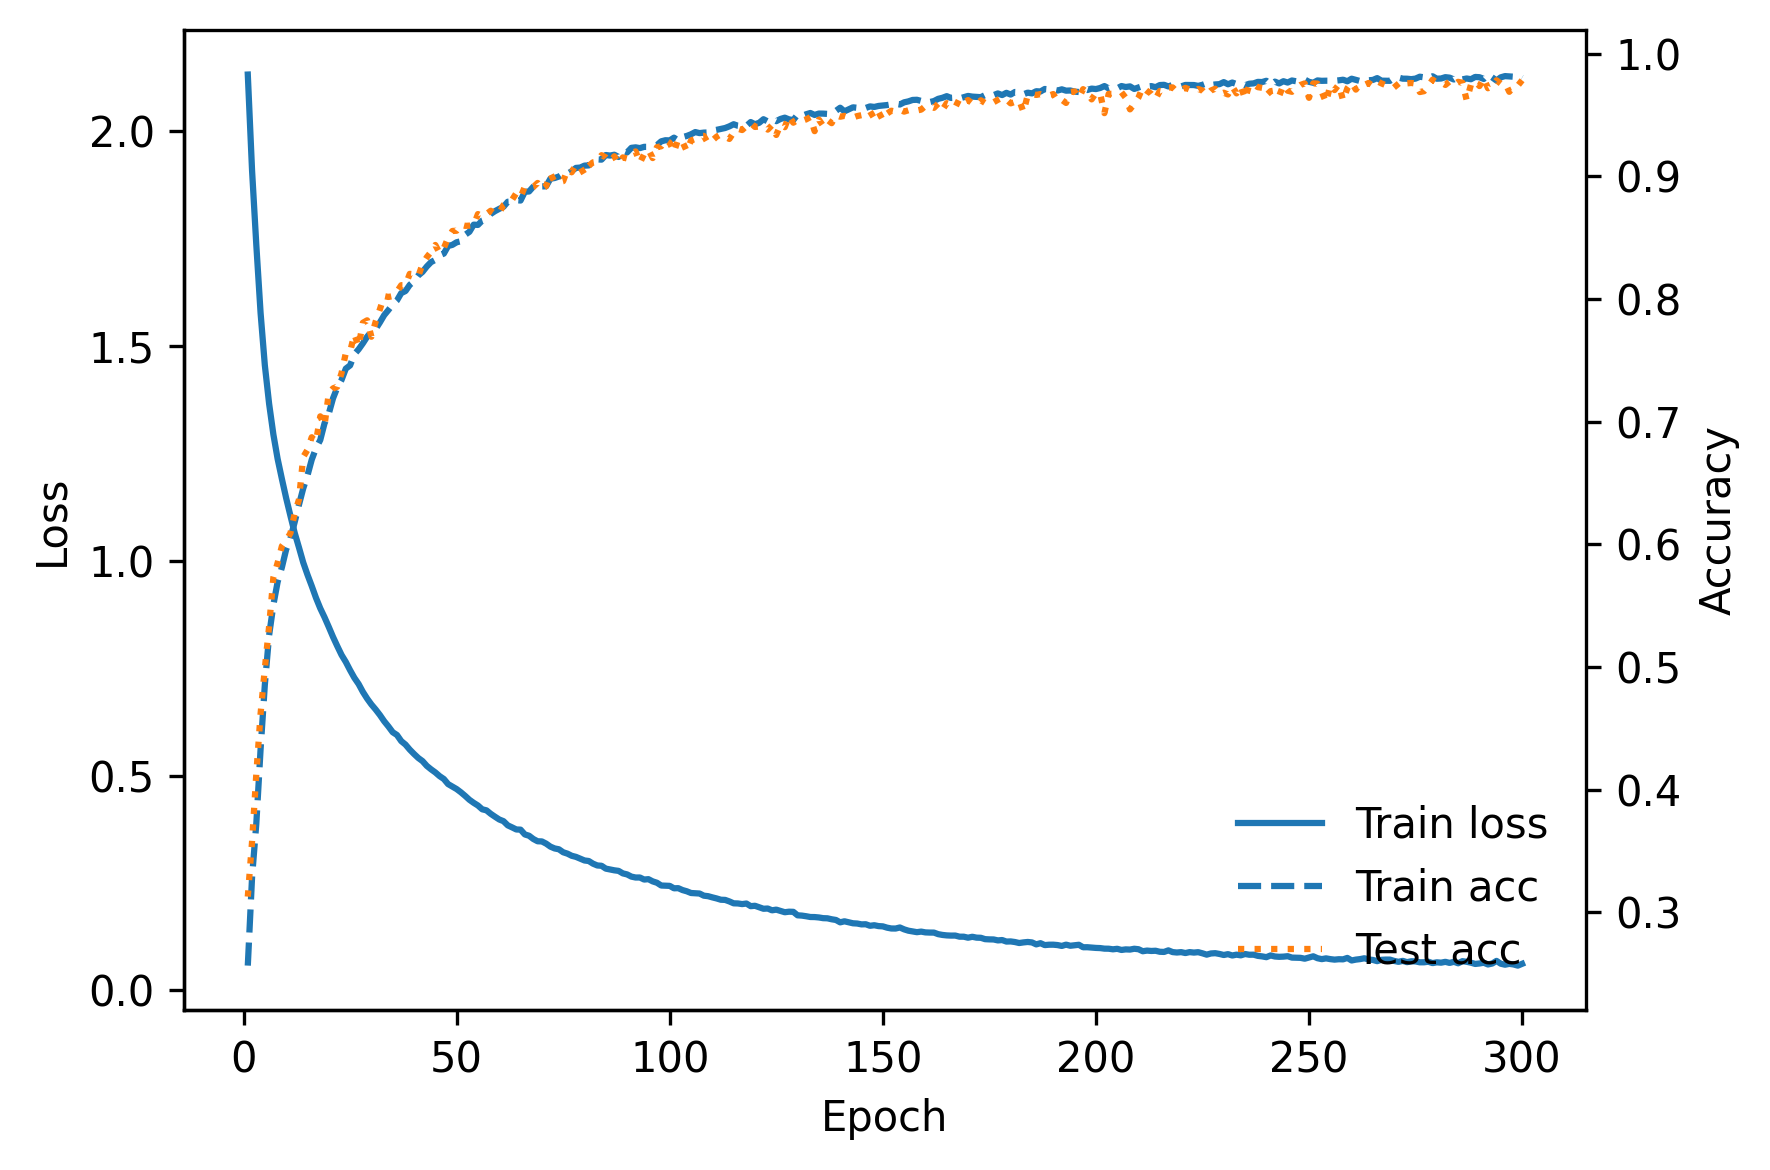

训练集样本： ['X209' 'X285' 'X058' 'X199' 'X059' 'X288' 'X236' 'X234' 'X133' 'X108'
 'X145' 'X159' 'X212' 'X222' 'X297' 'X276' 'X050' 'X158' 'X105' 'X259'
 'X249' 'X283' 'X130' 'X316' 'X312' 'X286' 'X281' 'X275' 'X311' 'X310'
 'X287' 'X261' 'X223' 'X282' 'X298' 'X313' 'X224' 'X186' 'X293' 'X299'
 'X273' 'X188' 'X292' 'X305' 'X132' 'X048' 'X197' 'X160' 'X306' 'X260'
 'X280' 'X057' 'X277' 'X315' 'X185' 'X247' 'X248' 'X210' 'X270' 'X146'
 'X056' 'X131' 'X295' 'X301' 'X198' 'X119' 'X309' 'X170' 'X049' 'X278'
 'X258' 'X156' 'X211' 'X237' 'X300' 'X271' 'X200' 'X291' 'X246' 'X172'
 'X169' 'X120' 'X318']
测试集样本： ['X296' 'X106' 'X284' 'X107' 'X235' 'X121' 'X274' 'X147' 'X225' 'X118'
 'X171' 'X144' 'X187' 'X279' 'X289' 'X302' 'X272' 'X294' 'X307' 'X290'
 'X317']
训练集大小: 21787, 测试集大小: 5796
特征维度: 40
X_train: (21787, 40)
y_train: (21787,)
X_test : (5796, 40)
y_test : (5796,)
DBN input_dim = 40 , n_classes = 11
Pretraining RBM layer 1/2
  Epoch 1/80, recon loss = 0.240091
  Epoch 2/80, recon loss = 0.163722

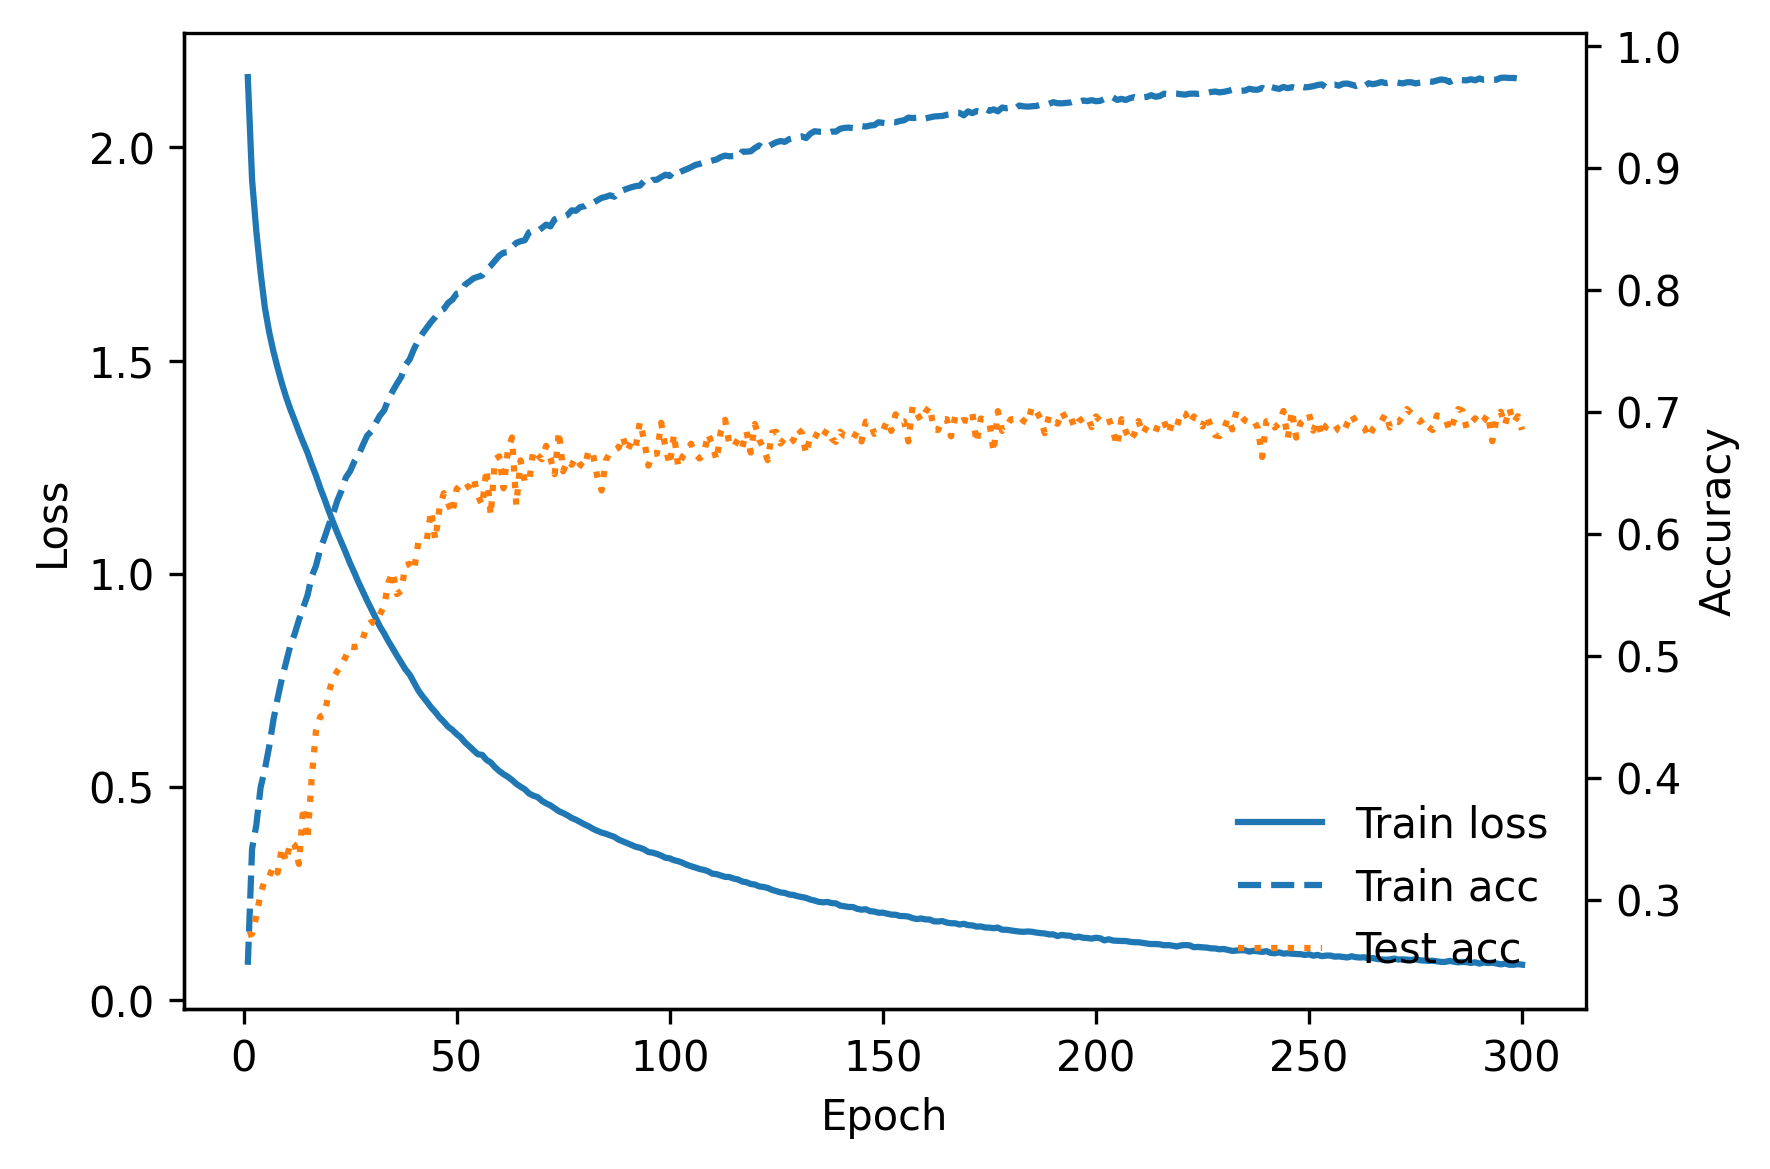

[save_results_df] 结果已保存到：E:\故障诊断2\实验整理\result\df\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024_result2.pkl
[plot_models_for_env] 图已保存到：E:\故障诊断2\实验整理\result\figs\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024_env_all_feature_models.png


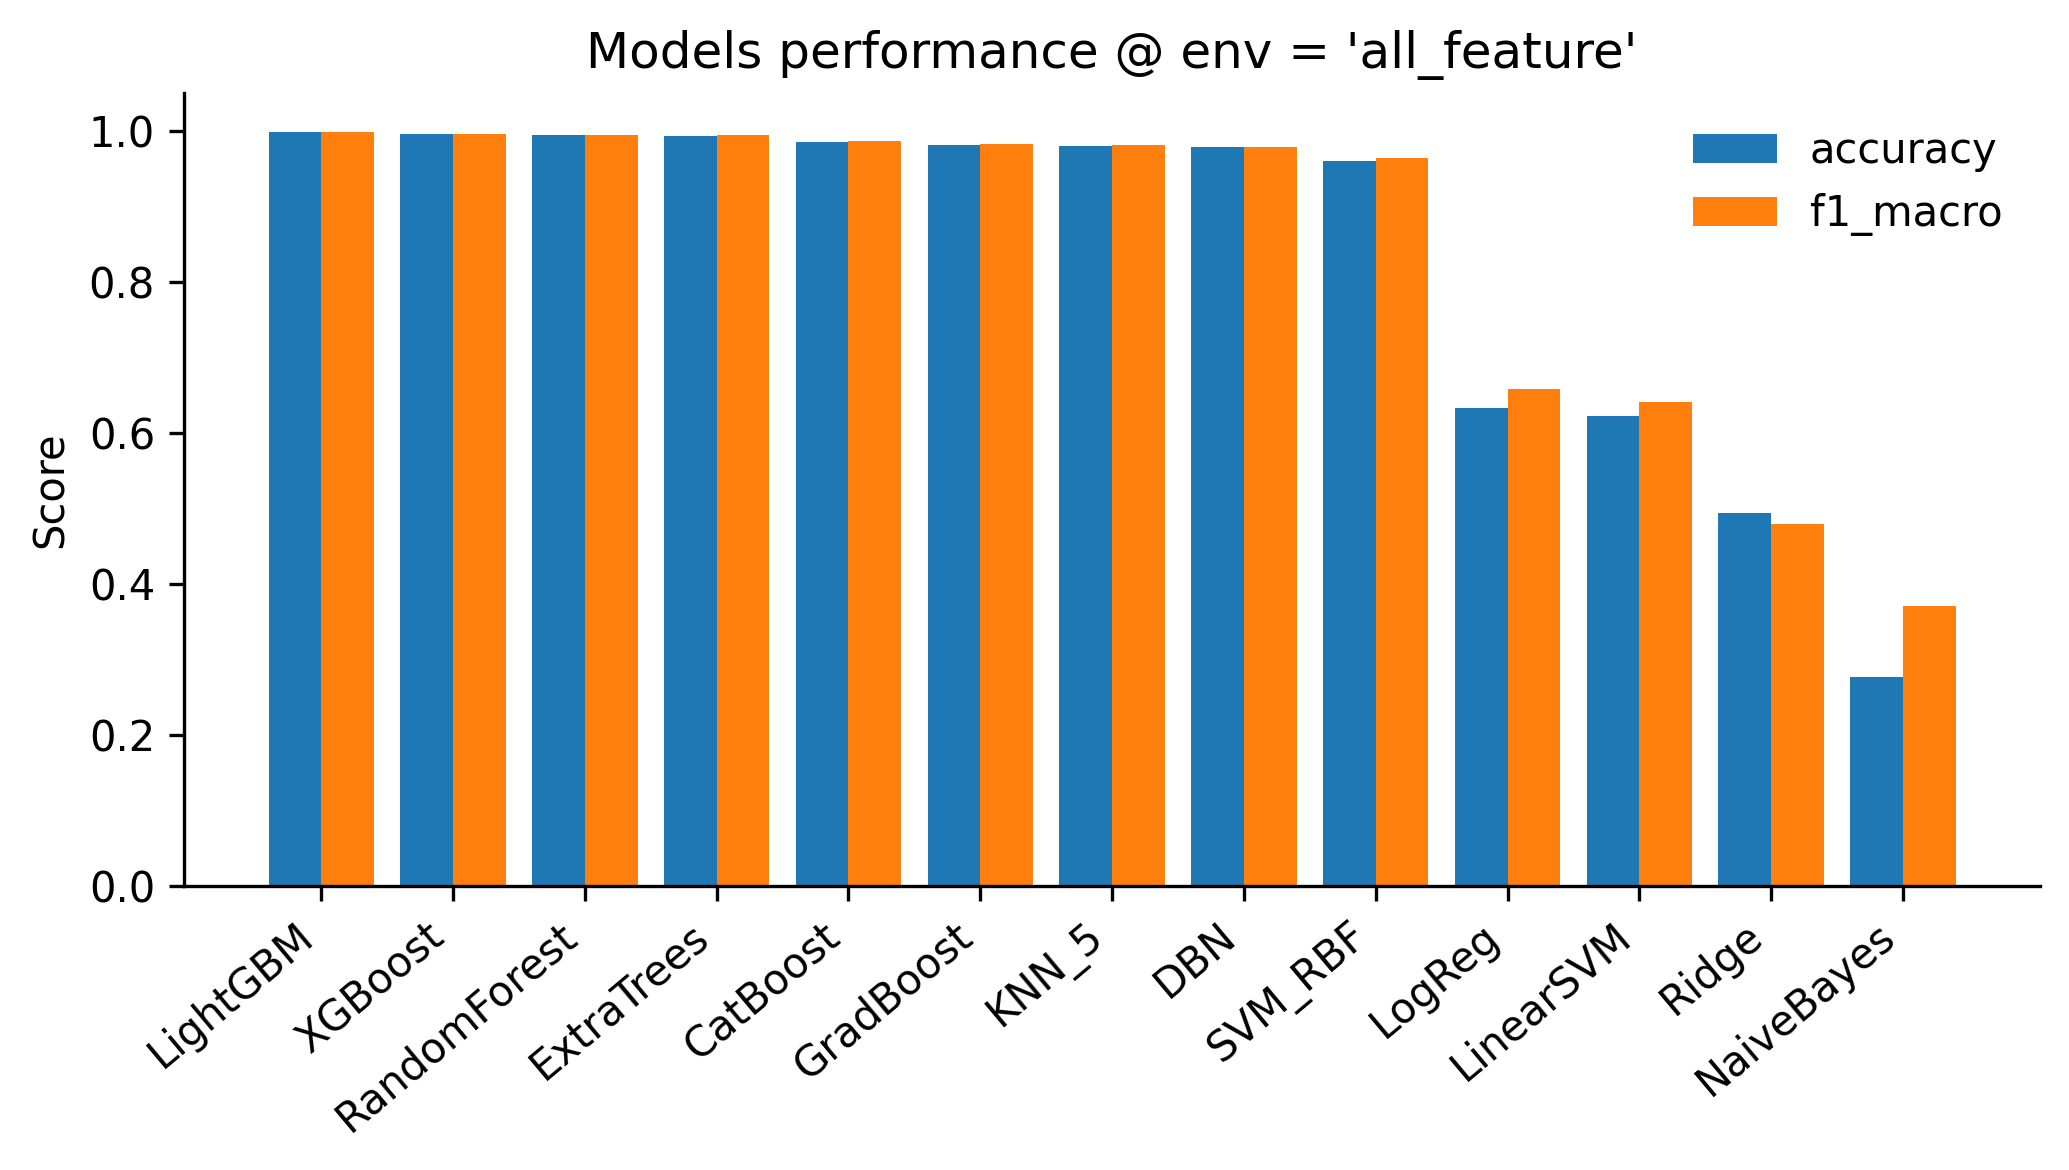

[plot_models_for_env] 图已保存到：E:\故障诊断2\实验整理\result\figs\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024_env_all_feature_fc_models.png


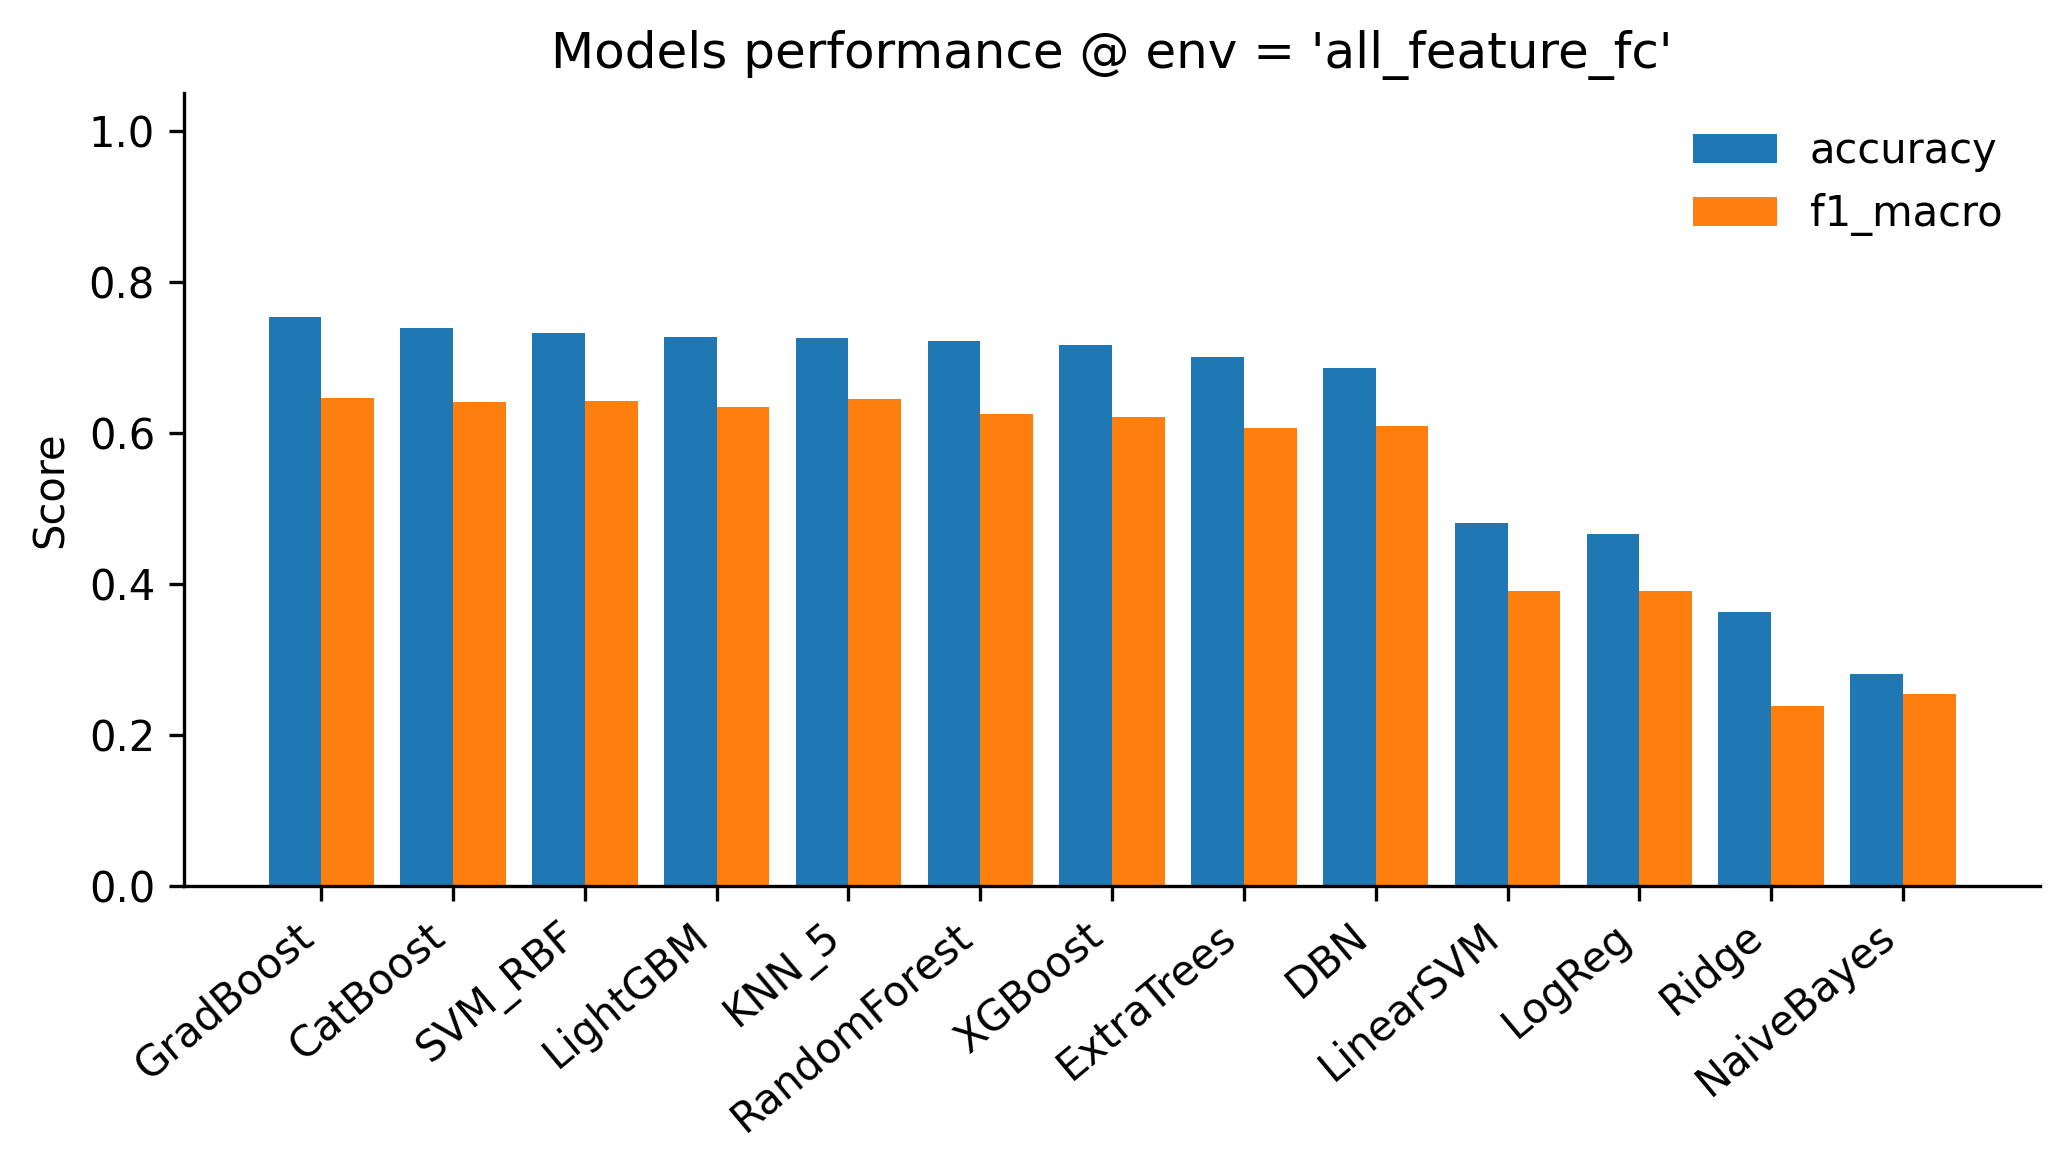

=== 全流程执行完成 ===


In [3]:
CONFIG = {
    "sampling_rates": ['12'],       # None 或 [] 表示不筛选;12,48,好像只能单独选一个
    "sampling_positions": ["DE",'BA','FE'],    
    "bearing_positions": None,       #['FE', 'DE', 'Normal']
    "loads": ['0', '1', '2','3'],    #载荷大小     
    "rpms": None,                    # 不筛选转速
    "fault_types": None,             # 不筛选故障类型
    "or_positons": []                # [None, 'Centered', 'Opposite', 'Orthogonal']
}
#设定数据分区方式
WINDOW_SIZE = 2048
STEP_SIZE = 1024

#保存路径
SAVE_DIR = r'E:\故障诊断2\实验整理\dataset\processed\npz'
CSV_SAVE_DIR =  r'E:\故障诊断2\实验整理\dataset\processed\csv'

RESULT_PATH = r'E:\故障诊断2\实验整理\result\df'
RESULT_PATH_FIG = r'E:\故障诊断2\实验整理\result\figs'

if __name__ == "__main__":
    main_bearing_fault_diagnosis(
        pickle_path='E:\故障诊断2\实验整理\dataset\processed\CWRU_bearing_dataset.pkl',
        save_dir=SAVE_DIR,
        csv_save_dir=CSV_SAVE_DIR,
        result_path=RESULT_PATH,
        result_fig_path=RESULT_PATH_FIG,
        window_size=WINDOW_SIZE,
        step_size=STEP_SIZE,
        config=CONFIG
    )
    print("=== 全流程执行完成 ===")

In [ ]:
df = pd.read_pickle(os.path.join(RESULT_PATH, f'{core_name[:-4]}_result.pkl'))

accuracy  f1_macro
env            model                           
all_feature    LightGBM      0.985925  0.981523
               XGBoost       0.982172  0.977140
               SVM_RBF       0.973493  0.965143
               RandomForest  0.972320  0.964152
               GradBoost     0.970678  0.962808
               ExtraTrees    0.969505  0.960786
               CatBoost      0.966925  0.958637
               KNN_5         0.932207  0.911582
               LogReg        0.899836  0.865177
               LinearSVM     0.893033  0.855386
               Ridge         0.746423  0.632861
               NaiveBayes    0.527563  0.487308
all_feature_fc SVM_RBF       0.812385  0.575669
               LightGBM      0.798803  0.500862
               RandomForest  0.796501  0.497764
               CatBoost      0.790516  0.495997
               ExtraTrees    0.789365  0.556773
               XGBoost       0.785451  0.485603
               GradBoost     0.771639  0.530547
               KNN_5         0.744475  0.465802
               LogReg        0.703959  0.373095
               LinearSVM     0.697284  0.364898
               Ridge         0.573204  0.252859
               NaiveBayes    0.416436  0.229444